In [1]:
from fastai.vision.all import *

In [2]:
torch.cuda.is_available()


True

In [3]:
from make import load_secondary_data

all_spectrograms, all_labels = load_secondary_data()

Generated 1 spectrograms - label: Controlled Fall
Generated 1 spectrograms - label: Controlled Fall
Generated 1 spectrograms - label: Controlled Fall
Generated 1 spectrograms - label: Controlled Fall
Generated 1 spectrograms - label: Controlled Fall
Generated 1 spectrograms - label: Controlled Fall
Generated 1 spectrograms - label: Controlled Fall
Generated 1 spectrograms - label: Controlled Fall
Generated 1 spectrograms - label: Controlled Fall
Generated 1 spectrograms - label: Controlled Fall
Generated 1 spectrograms - label: Controlled Fall
Generated 1 spectrograms - label: Controlled Fall
Generated 1 spectrograms - label: Controlled Fall
Generated 1 spectrograms - label: Controlled Fall
Generated 1 spectrograms - label: Controlled Fall
Generated 1 spectrograms - label: Controlled Fall
Generated 1 spectrograms - label: Controlled Fall
Generated 1 spectrograms - label: Controlled Fall
Generated 1 spectrograms - label: Controlled Fall
Generated 1 spectrograms - label: Controlled Fall


In [4]:
from validation_util import split, get_label_index

valid_spec, valid_labels = split(all_spectrograms, 60, labels=all_labels)

In [5]:
# constants you can tweak once
FLOOR_DB   = -5.0          # dynamic‑range floor, in dB
TARGET_HW  = (112,112)     # (H, W)
TARGET_CH = 6
EPS = 1e-12
RESIZE_HW  = None

In [6]:
import matplotlib.cm as cm
from matplotlib.colors import Normalize

def get_x(i : int):
        arr = all_spectrograms[i]

        # If spectrogram is multi-channel, convert to grayscale first
        if len(arr.shape) == 3:
                arr = np.mean(arr, axis=-1)  # average across channels
        
        #arr_01 = arr_01[:, ::-1].copy() # flip spectrogram
        
        # Apply colormap to convert grayscale to color
        # Popular colormaps for spectrograms: 'viridis', 'plasma', 'magma', 'inferno', 'jet', 'hot'
        colormap = plt.get_cmap('hot')  # or try 'plasma', 'magma', 'jet'
        arr_colored = colormap(arr)  # This returns RGBA (H, W, 4)
        
        # Convert RGBA to RGB (drop alpha channel)
        arr_rgb = arr_colored[:, :, :3]  # (H, W, 3)
        
        # Convert to PyTorch tensor with correct channel ordering
        t = torch.tensor(arr_rgb).float().permute(2, 0, 1).unsqueeze(0)  # (1, 3, H, W)
        
        # Resize image
        t_resized = torch.nn.functional.interpolate(t, size=TARGET_HW, mode='bilinear', align_corners=False)
        
        return TensorImage(t_resized.squeeze(0))  # (3, H, W)

def get_y(i):
    return all_labels[i]

In [7]:
block = DataBlock(
    blocks=(TransformBlock(), CategoryBlock(sort=False)),
    get_items=lambda x: x,
    get_x=get_x,
    get_y=get_y,
)

In [8]:
items = list(range(len(all_spectrograms)))   # or `range(N)`
dls = block.dataloaders(items, bs=12)

In [9]:
model = nn.Sequential(
    
    nn.Conv2d(3, 8, kernel_size=4, stride=2),     # (8, 55, 55)
    nn.BatchNorm2d(8),
    nn.ReLU(),
            
    nn.Conv2d(8, 16, kernel_size=3, stride=2),     # (16, 27, 27)
    nn.BatchNorm2d(16),
    nn.ReLU(),
        
    nn.Conv2d(16, 32, kernel_size=3, stride=2),    # (32, 13, 13)
    nn.BatchNorm2d(32),
    nn.ReLU(),

    nn.Conv2d(32, 64, kernel_size=3, stride=2),    # (64, 6, 6)
    nn.BatchNorm2d(64),
    nn.ReLU(),

    nn.Flatten(),
    nn.Linear(64*6*6, 14)
)

In [10]:
learner = Learner(dls, model, loss_func=CrossEntropyLossFlat(), metrics=accuracy)

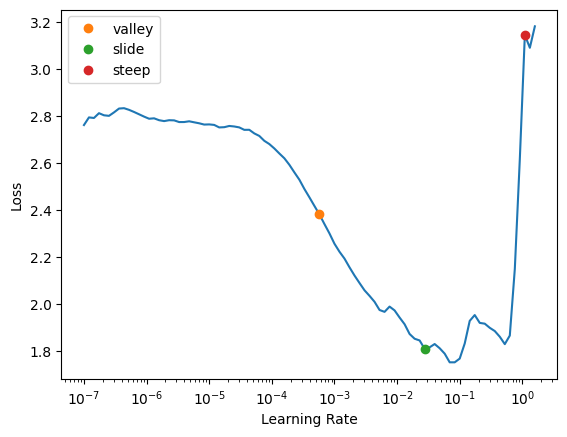

In [11]:
lr = learner.lr_find(suggest_funcs=(valley,slide,steep))

In [12]:
learner.fit_one_cycle(30, lr.valley)

epoch,train_loss,valid_loss,accuracy,time
0,2.211655,2.020824,0.361111,00:00
1,1.596892,1.125896,0.379630,00:00
2,1.241050,1.006470,0.481481,00:00
3,0.978630,0.796839,0.731481,00:00
4,0.732984,0.671633,0.768519,00:00
5,0.506973,0.528404,0.814815,00:00
6,0.335871,0.486147,0.842593,00:00
7,0.209521,0.419665,0.851852,00:00
8,0.129791,0.402885,0.842593,00:00
9,0.080372,0.394177,0.842593,00:00


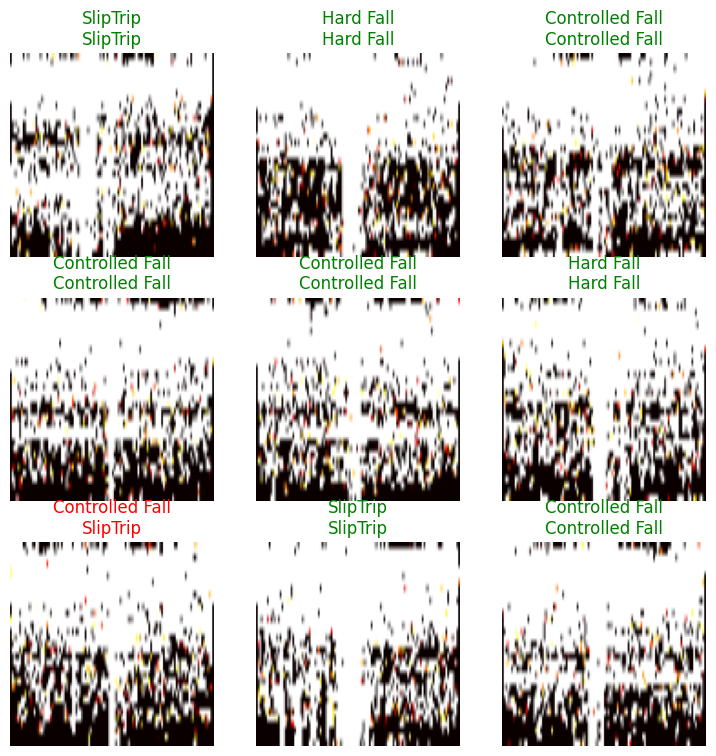

In [13]:
learner.show_results()

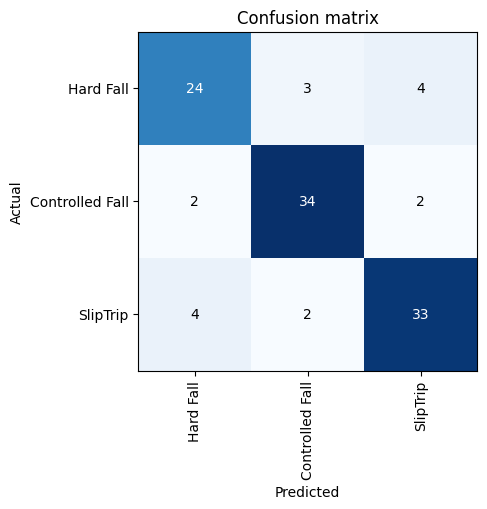

In [14]:
inter_plot = ClassificationInterpretation.from_learner(learner)
inter_plot.plot_confusion_matrix(figsize=(5,5))

In [15]:
dir = Path('./models')

learner.path = dir

learner.export('classic_cnn.pkl')

In [19]:
def get_x_test(i):
    arr = valid_spec[i]

    # If spectrogram is multi-channel, convert to grayscale first
    if len(arr.shape) == 3:
        arr = np.mean(arr, axis=-1)  # average across channels
    
    #arr_01 = arr_01[:, ::-1].copy() # flip spectrogram
    
    # Apply colormap to convert grayscale to color
    # Popular colormaps for spectrograms: 'viridis', 'plasma', 'magma', 'inferno', 'jet', 'hot'
    colormap = plt.get_cmap('hot')  # or try 'plasma', 'magma', 'jet'
    arr_colored = colormap(arr)  # This returns RGBA (H, W, 4)
    
    # Convert RGBA to RGB (drop alpha channel)
    arr_rgb = arr_colored[:, :, :3]  # (H, W, 3)
    
    # Convert to PyTorch tensor with correct channel ordering
    t = torch.tensor(arr_rgb).float().permute(2, 0, 1).unsqueeze(0)  # (1, 3, H, W)
    
    # Resize image
    t_resized = torch.nn.functional.interpolate(t, size=TARGET_HW, mode='bilinear', align_corners=False)
    
    return TensorImage(t_resized.squeeze(0))  # (3, H, W)


def get_y_test(i):
    return valid_labels[i]

In [16]:
def get_y_pred(learner: Learner, val_set : list):
    y_pred = []
    y_test = []
    
    for i in range(len(val_set)):
        y_pred.append(learner.predict(get_x_test(i))[0])
        y_test.append(get_y_test(i))
    return y_pred, y_test

In [17]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, ConfusionMatrixDisplay

In [20]:
y_pred, y_test = get_y_pred(learner, valid_spec)

In [21]:
learner.validate()

(#2) [0.3942507207393646,0.8425925970077515]

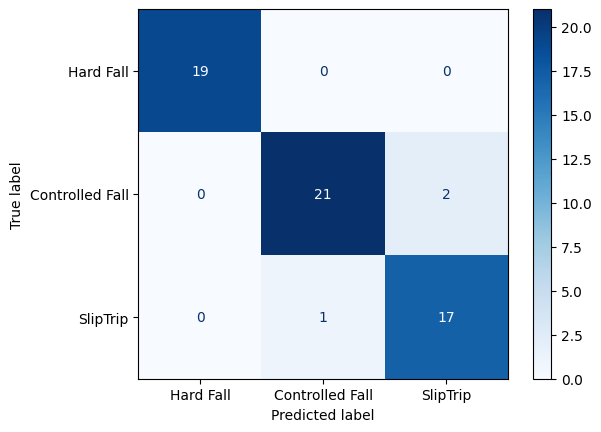

In [22]:
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(cm, display_labels=dls.vocab)
disp.plot(cmap="Blues")  # customize as you like
plt.show()

In [23]:
accuracy_score(y_test, y_pred)

0.95

In [24]:
precision_score(y_test, y_pred, average='weighted')

0.9509968102073365

In [25]:
recall_score(y_test, y_pred, average="weighted")

0.95

In [26]:
f1_score(y_test, y_pred, average="weighted")

0.9501201201201201